# Sanity Checks — NSGT Integration

This notebook validates correctness and consistency of the NSGT implementation  
against the existing STFT and mel representations.  
It is **not** for experimentation — only for integration testing.

| Section | What it checks |
|---|---|
| 2 | Output shapes and dtypes |
| 3 | No NaN / Inf values |
| 4 | Linearity: mixing `x` with itself (`x + x = 2x`) |
| 5 | Zero signal: mixing `x` with silence |
| 6 | `rep_x + rep_y` is computable and shape-consistent with `rep_mix` |
| 7 | Visual inspection of all three transforms |

## 1. Setup

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np

# Suppress nsgt3 / librosa UserWarnings to keep output readable
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

In [2]:
from spectral_mixture_analysis.audio import load_mono_audio, match_length
from spectral_mixture_analysis.transforms import compute_representation, amplitude_to_db
from spectral_mixture_analysis.analysis import evaluate_mixture_linearity

In [3]:
audio_path_x = PROJECT_ROOT / "data" / "raw" / "audio01_bass.wav"
audio_path_y = PROJECT_ROOT / "data" / "raw" / "audio02_vocal.wav"

x, sr = load_mono_audio(audio_path_x, sr=22050)
y, _  = load_mono_audio(audio_path_y, sr=22050)
x, y  = match_length(x, y, mode="truncate")

print(f"x : {len(x)} samples  ({len(x)/sr:.2f} s)  sr={sr}")
print(f"y : {len(y)} samples  ({len(y)/sr:.2f} s)  sr={sr}")

x : 88200 samples  (4.00 s)  sr=22050
y : 88200 samples  (4.00 s)  sr=22050


In [4]:
# Transform parameters used consistently throughout all checks.
# Defined once here so every section stays in sync.
STFT_KWARGS = dict(output="magnitude", n_fft=2048, hop_length=512)
MEL_KWARGS  = dict(n_fft=2048, hop_length=512)
NSGT_KWARGS = dict(fmin=30.0, fmax=11000.0, bins=48, scale="oct")

TRANSFORMS = {
    "stft": STFT_KWARGS,
    "mel" : MEL_KWARGS,
    "nsgt": NSGT_KWARGS,
}

## 2. Representation Shape and Type Checks

For each transform, verify that:
- The output is a **2D** numpy array
- The dtype is a **numeric float** type (not `object`)
- The shapes of `rep_x`, `rep_y`, and `rep_mix` are **identical**
  (required for `rep_x + rep_y` to be well-defined and for metric computation)

In [5]:
mix = x + y

for name, kwargs in TRANSFORMS.items():
    rep_x   = compute_representation(x,   sr, transform_type=name, **kwargs)
    rep_y   = compute_representation(y,   sr, transform_type=name, **kwargs)
    rep_mix = compute_representation(mix, sr, transform_type=name, **kwargs)

    print(f"[{name.upper()}]")
    print(f"  rep_x   shape={rep_x.shape}  dtype={rep_x.dtype}")
    print(f"  rep_y   shape={rep_y.shape}  dtype={rep_y.dtype}")
    print(f"  rep_mix shape={rep_mix.shape}  dtype={rep_mix.dtype}")

    assert rep_x.ndim == 2,   f"{name}: rep_x is not 2D (got {rep_x.ndim}D)"
    assert rep_y.ndim == 2,   f"{name}: rep_y is not 2D"
    assert rep_mix.ndim == 2, f"{name}: rep_mix is not 2D"

    assert rep_x.dtype != object,   f"{name}: rep_x has object dtype"
    assert rep_y.dtype != object,   f"{name}: rep_y has object dtype"
    assert rep_mix.dtype != object, f"{name}: rep_mix has object dtype"

    assert rep_x.shape == rep_y.shape == rep_mix.shape, (
        f"{name}: inconsistent shapes — x:{rep_x.shape}  y:{rep_y.shape}  mix:{rep_mix.shape}"
    )

    print(f"  PASS — 2D, numeric dtype, consistent shape {rep_x.shape}\n")

print("All shape / type checks passed.")

[STFT]
  rep_x   shape=(1025, 173)  dtype=float32
  rep_y   shape=(1025, 173)  dtype=float32
  rep_mix shape=(1025, 173)  dtype=float32
  PASS — 2D, numeric dtype, consistent shape (1025, 173)

[MEL]
  rep_x   shape=(128, 173)  dtype=float32
  rep_y   shape=(128, 173)  dtype=float32
  rep_mix shape=(128, 173)  dtype=float32
  PASS — 2D, numeric dtype, consistent shape (128, 173)

[NSGT]
  rep_x   shape=(410, 1252)  dtype=float32
  rep_y   shape=(410, 1252)  dtype=float32
  rep_mix shape=(410, 1252)  dtype=float32
  PASS — 2D, numeric dtype, consistent shape (410, 1252)

All shape / type checks passed.


## 3. Finite Values Check

Verify that no representation contains `NaN` or `Inf`.  
These would silently corrupt all downstream metric computations.

In [6]:
for name, kwargs in TRANSFORMS.items():
    rep_x   = compute_representation(x,   sr, transform_type=name, **kwargs)
    rep_y   = compute_representation(y,   sr, transform_type=name, **kwargs)
    rep_mix = compute_representation(mix, sr, transform_type=name, **kwargs)

    checks = {
        "rep_x"  : np.isfinite(rep_x).all(),
        "rep_y"  : np.isfinite(rep_y).all(),
        "rep_mix": np.isfinite(rep_mix).all(),
    }

    print(f"[{name.upper()}]")
    for label, ok in checks.items():
        status = "PASS" if ok else "FAIL — contains NaN or Inf"
        print(f"  {label:10s} finite={ok}  {status}")
        assert ok, f"{name}: {label} contains NaN or Inf"
    print()

print("All finite-value checks passed.")

[STFT]
  rep_x      finite=True  PASS
  rep_y      finite=True  PASS
  rep_mix    finite=True  PASS

[MEL]
  rep_x      finite=True  PASS
  rep_y      finite=True  PASS
  rep_mix    finite=True  PASS

[NSGT]
  rep_x      finite=True  PASS
  rep_y      finite=True  PASS
  rep_mix    finite=True  PASS

All finite-value checks passed.


## 4. Linearity Sanity Check: x = y (mixture = 2x)

When both inputs are the same signal, the mixture is `2x`.  
The expected behavior depends on how each transform handles amplitude scaling:

| Transform | `R(2x)` | `R(x) + R(x)` | Expected error |
|---|---|---|---|
| STFT magnitude | `2\|stft(x)\|` | `2\|stft(x)\|` | `relative_l2 ≈ 0` |
| NSGT magnitude | `2\|nsgt(x)\|` | `2\|nsgt(x)\|` | `relative_l2 ≈ 0` |
| mel (power=2.0) | `4·mel(x)` | `2·mel(x)` | `relative_l2 ≈ 0.50` |

The mel result is **not a bug** — power spectrograms are quadratic by design.  
The check for mel asserts the relative error is close to **0.50**, not 0.

In [7]:
for name, kwargs in TRANSFORMS.items():
    metrics = evaluate_mixture_linearity(x, x, sr=sr, transform_type=name, **kwargs)
    rel = metrics["relative_l2"]

    print(f"[{name.upper()}]  relative_l2={rel:.6f}  l2={metrics['l2']:.4f}")

    if name == "mel":
        # mel (power=2) is quadratic: R(2x) = 4·R(x), R(x)+R(x) = 2·R(x)
        # relative error = ||4R - 2R|| / ||4R|| = 2||R|| / 4||R|| = 0.50
        assert abs(rel - 0.5) < 0.01, f"mel x=y: expected relative_l2 ≈ 0.50, got {rel:.4f}"
        print(f"  PASS — mel (power=2) quadratic behavior confirmed: relative_l2 ≈ 0.50\n")
    else:
        assert rel < 1e-5, f"{name} x=y: expected relative_l2 ≈ 0, got {rel:.2e}"
        print(f"  PASS — magnitude representation is linear: relative_l2 ≈ 0\n")

print("All x=y linearity checks passed.")

[STFT]  relative_l2=0.000000  l2=0.0000
  PASS — magnitude representation is linear: relative_l2 ≈ 0

[MEL]  relative_l2=0.500000  l2=10742.6006
  PASS — mel (power=2) quadratic behavior confirmed: relative_l2 ≈ 0.50

[NSGT]  relative_l2=0.000000  l2=0.0000
  PASS — magnitude representation is linear: relative_l2 ≈ 0

All x=y linearity checks passed.


## 5. Zero Signal Sanity Check: y = zeros

When one signal is silence (`y = 0`):
- `R(0) = 0` for all transforms
- `R(x + 0) = R(x)`
- Therefore `R(x + y) = R(x) = R(x) + R(y)` → **error = 0 for all transforms**

This holds even for mel (power=2), because adding silence does not change the signal.

In [8]:
y_zero = np.zeros_like(x)

for name, kwargs in TRANSFORMS.items():
    metrics = evaluate_mixture_linearity(x, y_zero, sr=sr, transform_type=name, **kwargs)
    rel = metrics["relative_l2"]

    print(f"[{name.upper()}]  relative_l2={rel:.2e}  l2={metrics['l2']:.2e}")
    assert rel < 1e-5, f"{name} zero-y: expected relative_l2 ≈ 0, got {rel:.2e}"
    print(f"  PASS\n")

print("All zero-signal checks passed.")

[STFT]  relative_l2=0.00e+00  l2=0.00e+00
  PASS

[MEL]  relative_l2=0.00e+00  l2=0.00e+00
  PASS

[NSGT]  relative_l2=0.00e+00  l2=0.00e+00
  PASS

All zero-signal checks passed.


## 6. Representation Consistency Check

Verify that `rep_x + rep_y`:
- Does **not** raise an error
- Produces a finite result
- Has the **same shape** as `rep_mix`

This is required for `evaluate_mixture_linearity` to work correctly.

In [9]:
for name, kwargs in TRANSFORMS.items():
    rep_x   = compute_representation(x,   sr, transform_type=name, **kwargs)
    rep_y   = compute_representation(y,   sr, transform_type=name, **kwargs)
    rep_mix = compute_representation(mix, sr, transform_type=name, **kwargs)

    rep_sum = rep_x + rep_y  # must not raise

    assert rep_sum.shape == rep_mix.shape, (
        f"{name}: rep_sum shape {rep_sum.shape} != rep_mix shape {rep_mix.shape}"
    )
    assert np.isfinite(rep_sum).all(), f"{name}: rep_sum contains NaN or Inf"

    print(f"[{name.upper()}]  rep_x + rep_y  shape={rep_sum.shape}  matches rep_mix: PASS")

print("\nAll consistency checks passed.")

[STFT]  rep_x + rep_y  shape=(1025, 173)  matches rep_mix: PASS
[MEL]  rep_x + rep_y  shape=(128, 173)  matches rep_mix: PASS
[NSGT]  rep_x + rep_y  shape=(410, 1252)  matches rep_mix: PASS

All consistency checks passed.


## 7. Basic Visualization

Plot `rep_x`, `rep_y`, and `rep_mix` (in dB) for each transform.  
Visual inspection confirms that the representations look reasonable and  
that NSGT output is structurally similar to STFT/mel (time × frequency image).

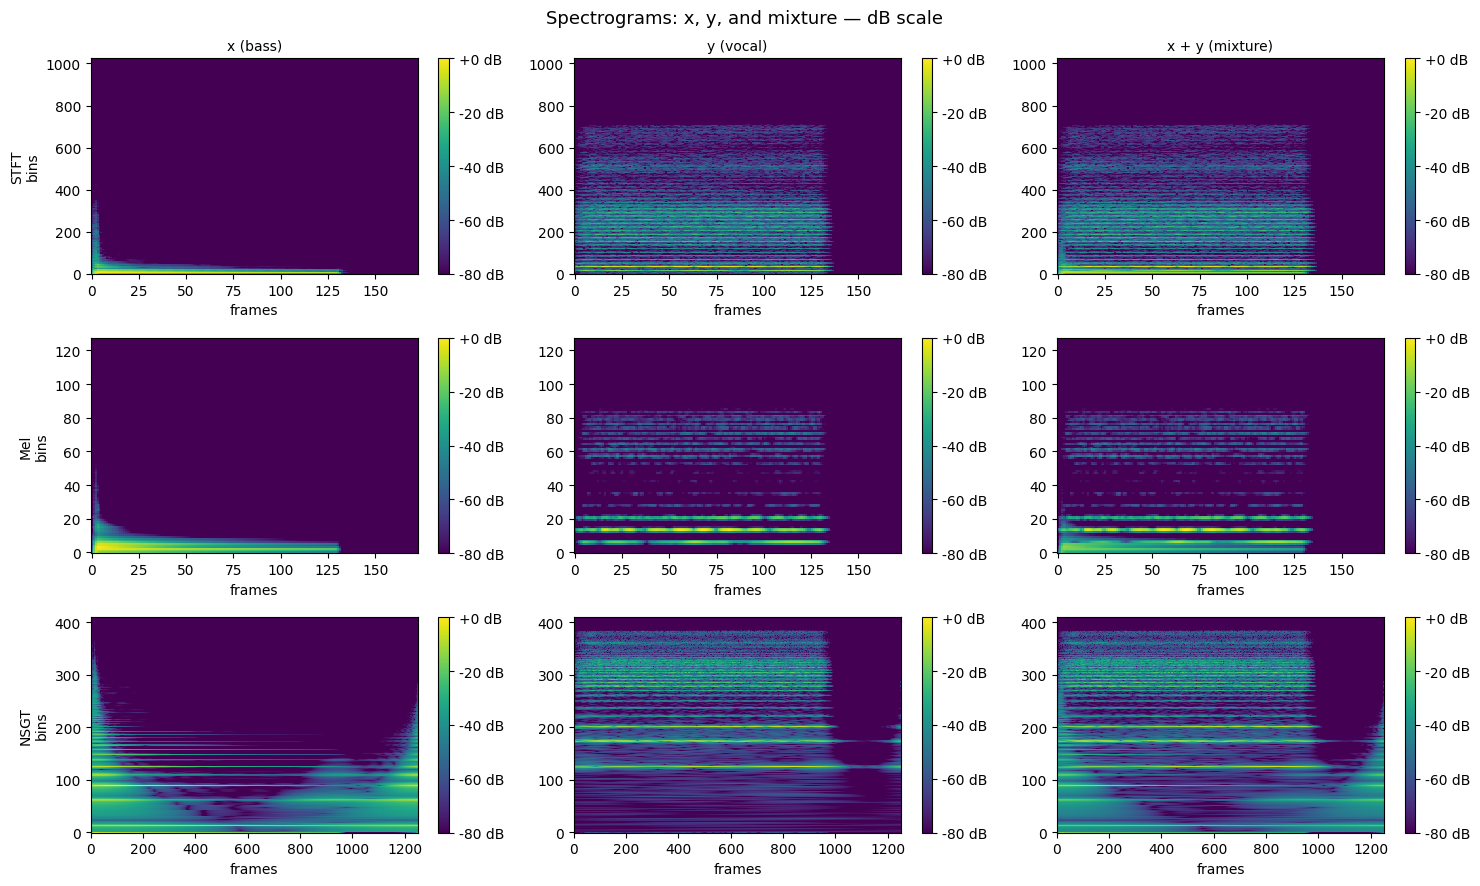

In [10]:
import matplotlib.pyplot as plt

col_titles  = ["x (bass)", "y (vocal)", "x + y (mixture)"]
row_titles  = ["STFT", "Mel", "NSGT"]
signals     = [x, y, mix]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
fig.suptitle("Spectrograms: x, y, and mixture — dB scale", fontsize=13)

for row_idx, (name, kwargs) in enumerate(TRANSFORMS.items()):
    for col_idx, sig in enumerate(signals):
        rep = compute_representation(sig, sr, transform_type=name, **kwargs)
        rep_db = amplitude_to_db(rep)

        ax = axes[row_idx, col_idx]
        im = ax.imshow(rep_db, origin="lower", aspect="auto", interpolation="none")
        plt.colorbar(im, ax=ax, format="%+2.0f dB")

        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(row_titles[row_idx], fontsize=10)
        ax.set_xlabel("frames")
        ax.set_ylabel(f"{row_titles[row_idx]}\nbins" if col_idx == 0 else "")

plt.tight_layout()
plt.show()

## Summary

All programmatic checks are run with `assert` statements.  
If this notebook executes without errors, the NSGT integration is correct.

| Check | STFT | Mel | NSGT |
|---|---|---|---|
| Output is 2D float array | ✓ | ✓ | ✓ |
| No NaN / Inf | ✓ | ✓ | ✓ |
| x=y → expected error | ≈ 0 | ≈ 0.50 (quadratic) | ≈ 0 |
| y=0 → error ≈ 0 | ✓ | ✓ | ✓ |
| rep_x + rep_y shape consistent | ✓ | ✓ | ✓ |